# Spurious Correlation: Divorce Rate in Maine vs. Margarine Consumption
A stunning example from Tyler Vigen's spurious correlations dataset (2000–2009) with an almost perfect correlation.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import numpy as np

## Define the Dataset
Divorce rate in Maine (per 1000 people) and per capita margarine consumption in the US (pounds), 2000–2009.

In [9]:
data = {
    "Year": [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009],
    "Divorce_Rate_Maine": [5.0, 4.7, 4.6, 4.4, 4.3, 4.1, 4.2, 4.2, 4.2, 4.1],
    "Margarine_Consumption_Pounds": [8.2, 7.0, 6.5, 5.3, 5.2, 4.0, 4.6, 4.5, 4.2, 3.7],
}

df = pd.DataFrame(data)
df

,Year,Divorce_Rate_Maine,Margarine_Consumption_Pounds
0,2000,5.0,8.2
1,2001,4.7,7.0
2,2002,4.6,6.5
3,2003,4.4,5.3
4,2004,4.3,5.2
5,2005,4.1,4.0
6,2006,4.2,4.6
7,2007,4.2,4.5
8,2008,4.2,4.2
9,2009,4.1,3.7


## Explore Data

In [10]:
print(df.describe())
print("\n")
df.info()

             Year  Divorce_Rate_Maine  Margarine_Consumption_Pounds
count    10.00000           10.000000                     10.000000
mean   2004.50000            4.380000                      5.320000
std       3.02765            0.297396                      1.465757
min    2000.00000            4.100000                      3.700000
25%    2002.25000            4.200000                      4.275000
50%    2004.50000            4.250000                      4.900000
75%    2006.75000            4.550000                      6.200000
max    2009.00000            5.000000                      8.200000


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          10 non-null     int64  
 1   Divorce_Rate_Maine            10 non-null     float64
 2   Margarine_Consumption_Pounds  10 non-null     float64
d

## Calculate Correlation Coefficient

In [11]:
correlation = df["Divorce_Rate_Maine"].corr(df["Margarine_Consumption_Pounds"])
print(f"The correlation coefficient is: {correlation:.4f}")

The correlation coefficient is: 0.9926


## Dual Y-Axis Visualization
Divorce rate in Maine (red, left axis) vs. per capita margarine consumption (gold, right axis).

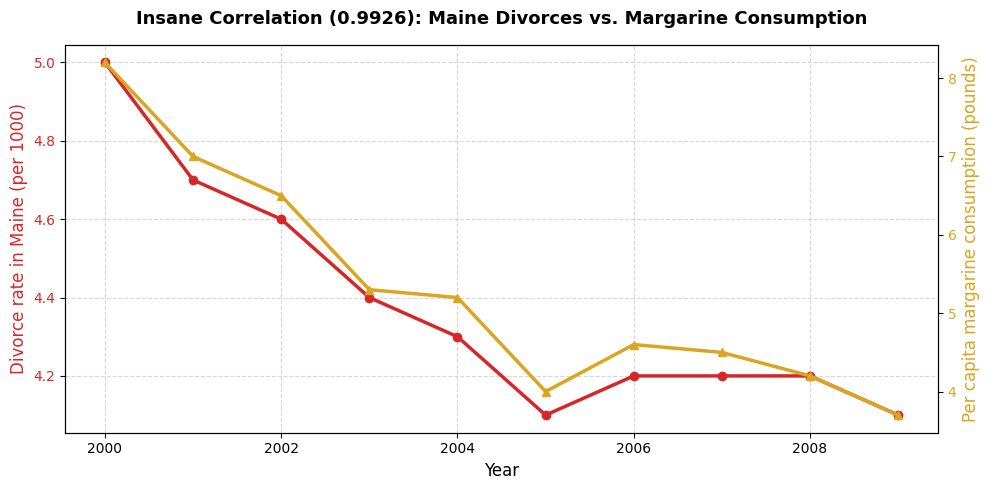

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: Divorce rate
color = "tab:red"
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Divorce rate in Maine (per 1000)", color=color, fontsize=12)
ax1.plot(df["Year"], df["Divorce_Rate_Maine"], color=color, marker="o", lw=2.5)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.5)

# Right axis: Margarine consumption
ax2 = ax1.twinx()
color = "goldenrod"
ax2.set_ylabel("Per capita margarine consumption (pounds)", color=color, fontsize=12)
ax2.plot(df["Year"], df["Margarine_Consumption_Pounds"], color=color, marker="^", lw=2.5)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(f"Insane Correlation ({correlation:.4f}): Maine Divorces vs. Margarine Consumption", fontsize=13, fontweight="bold", pad=15)
fig.tight_layout()
plt.show()

## Statistical Significance Test

In [13]:
r, p_value = stats.pearsonr(df["Divorce_Rate_Maine"], df["Margarine_Consumption_Pounds"])
print(f"Pearson correlation: r = {r:.4f}")
print(f"P-value: p = {p_value:.6f}")
print(f"\nStatistically significant (p < 0.05)? {'Yes' if p_value < 0.05 else 'No'}")
print(f"\nDespite this near-perfect correlation being highly significant,")
print("margarine consumption does NOT cause divorces in Maine!")

Pearson correlation: r = 0.9926
P-value: p = 0.000000

Statistically significant (p < 0.05)? Yes

Despite this near-perfect correlation being highly significant,
margarine consumption does NOT cause divorces in Maine!


## Scatter Plot with Regression Line

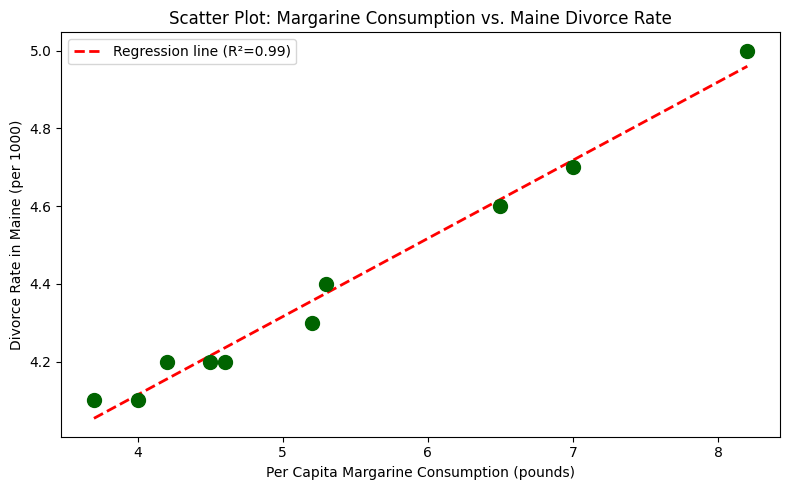


WHY CORRELATION DOES NOT IMPLY CAUSATION

This is perhaps the most famous spurious correlation example.
With r ≈ 0.99, it looks like margarine literally predicts divorce 
in Maine — but of course that's absurd.

Both variables simply declined at similar rates during 2000-2009.
This is what happens when you mine thousands of datasets for 
patterns: you WILL find coincidences that look convincing.

Key lesson: Even r = 0.99 with p < 0.001 means NOTHING 
without a plausible causal mechanism.

Source: Tyler Vigen - tylervigen.com/spurious-correlations



In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["Margarine_Consumption_Pounds"], df["Divorce_Rate_Maine"], color="darkgreen", s=100, zorder=5)

# Regression line
slope, intercept, r_value, p_val, std_err = stats.linregress(
    df["Margarine_Consumption_Pounds"], df["Divorce_Rate_Maine"]
)
x_line = np.linspace(df["Margarine_Consumption_Pounds"].min(), df["Margarine_Consumption_Pounds"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="red", linewidth=2, linestyle="--", label=f"Regression line (R²={r_value**2:.2f})")

ax.set_xlabel("Per Capita Margarine Consumption (pounds)")
ax.set_ylabel("Divorce Rate in Maine (per 1000)")
ax.set_title("Scatter Plot: Margarine Consumption vs. Maine Divorce Rate")
ax.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("WHY CORRELATION DOES NOT IMPLY CAUSATION")
print("="*60)
print("""
This is perhaps the most famous spurious correlation example.
With r ≈ 0.99, it looks like margarine literally predicts divorce 
in Maine — but of course that's absurd.

Both variables simply declined at similar rates during 2000-2009.
This is what happens when you mine thousands of datasets for 
patterns: you WILL find coincidences that look convincing.

Key lesson: Even r = 0.99 with p < 0.001 means NOTHING 
without a plausible causal mechanism.

Source: Tyler Vigen - tylervigen.com/spurious-correlations
""")